In [1]:
print("hello world")

hello world


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import numpy as np
from mpl_toolkits.mplot3d import Axes3D as ax
import glob

0
Number of rules per set: [3, 4, 2, 2, 2, 1, 1, 1, 1, 1, 4, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 4, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 3, 1, 1, 1, 1, 1, 1, 3, 1, 2, 3, 1, 2, 3, 3, 3, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 3, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 2, 3, 3, 3, 2, 2, 2, 3, 2, 2, 2, 1, 3, 2, 1, 1, 3, 1, 2, 1, 1, 1, 3, 3, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 3, 2, 2, 2, 2, 1, 3, 2, 3, 2, 1, 1, 2, 3, 2, 2, 2, 2, 2, 4, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 3, 2, 2, 3, 3, 4, 3, 2, 3, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2]


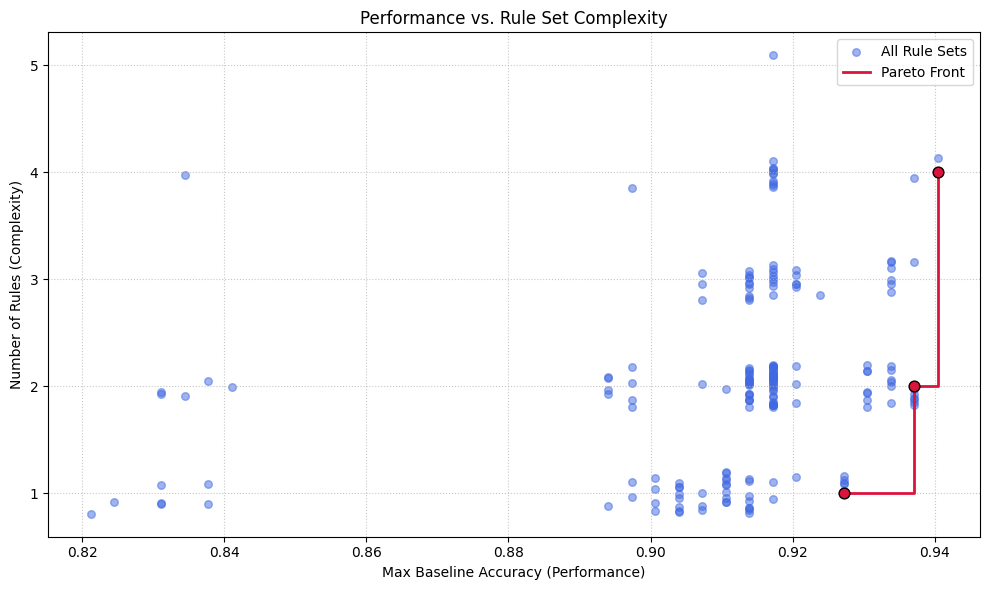

In [ ]:



experiment_dir = "../../../neurorule-data/multi-objective/bc/ID/0.95/0.0.1_20260223-141825/"
experiment_stats_file = experiment_dir + "experiment_stats.csv"
top_rules_column_name = "cid_max_baseline_accuracy"

df = pd.read_csv(experiment_stats_file)
top_rule_sets = df[top_rules_column_name]

top_num_rules = []

missing_count = 0
for rule_name in top_rule_sets:
    iteration, num = rule_name.split("_")
    rule_set_dir = experiment_dir + iteration
    rule_file_path = rule_set_dir + "/" + rule_name + ".rules"

    try:
        # Open and parse the JSON file
        with open(rule_file_path, 'r') as f:
            rule_data = json.load(f)
            # Count the number of rule objects in the 'rules' list
            num_rules = len(rule_data.get("rules", []))
            top_num_rules.append(num_rules)
    except FileNotFoundError:
        print(f"File not found: {rule_file_path}")
        top_num_rules.append(None)
        missing_count += 1

print("Files missing:", missing_count)


print(f"Number of rules per set: {top_num_rules}")

performance = df["max_baseline_accuracy"]
ood = df["max_out_of_distribution_accuracy"]
idd = df["max_in_distribution_accuracy"]



# 1. Prepare data for plotting
plot_df = pd.DataFrame({
    'num_rules': top_num_rules,
    'performance': performance,
    'ood_performance': ood,
    'idd_performance': idd
}).dropna()

# Filtering as per your original script
plot_df = plot_df[5:]

# 2. Calculate Pareto Front (Minimizing Complexity for a given Performance)
# Sort by performance (x-axis) ascending
df_sorted = plot_df.sort_values(by=['performance', 'num_rules'], ascending=[True, True])

pareto_front = []
current_min_rules = float('inf')

# To find the front where we minimize rules for a target performance, 
# we iterate backwards from highest performance
df_sorted_desc = plot_df.sort_values(by=['performance', 'num_rules'], ascending=[False, True])
current_min_rules = float('inf')

for _, row in df_sorted_desc.iterrows():
    if row['num_rules'] < current_min_rules:
        pareto_front.append((row['performance'], row['num_rules']))
        current_min_rules = row['num_rules']

# Sort back for plotting the line
pareto_front.sort()
pareto_x, pareto_y = zip(*pareto_front)

# 3. Create Visualization
plt.figure(figsize=(10, 6))

jitter = np.random.uniform(-0.2, 0.2, size=len(plot_df))
# Plot all data points (Performance on X, Num Rules on Y)
plt.scatter(plot_df['performance'], plot_df['num_rules'] + jitter, 
            color='royalblue', alpha=0.5, label='All Rule Sets', s=30)

# Plot the Pareto Front line
# 'where=pre' or 'post' depends on how you want the staircase to look
plt.step(pareto_x, pareto_y, where='post', color='crimson', 
         linewidth=2, label='Pareto Front', zorder=10)

# Highlight the points on the Pareto Front
plt.scatter(pareto_x, pareto_y, color='crimson', s=60, edgecolors='black', zorder=11)

# Swapped Labels
plt.xlabel('Max Baseline Accuracy (Performance)')
plt.ylabel('Number of Rules (Complexity)')
plt.title('Performance vs. Rule Set Complexity')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
# plt.savefig('pareto_analysis_swapped.png')
plt.show()

In [5]:
top_num_rules = []
top_num_conditions = []

for rule_name in top_rule_sets:
    try:
        iteration = rule_name.split("_")[0]
        rule_file_path = os.path.join(experiment_dir, iteration, f"{rule_name}.rules")
        
        with open(rule_file_path, 'r') as f:
            rule_data = json.load(f)
            rules_list = rule_data.get("rules", [])
            
            # Count individual rules
            top_num_rules.append(len(rules_list))
            
            # Count total conditions across all rules in this set
            total_conds = 0
            for r in rules_list:
                num_conds = len(r.get("conditions", []))
                total_conds += num_conds
                
            top_num_conditions.append(total_conds)
            
    except (FileNotFoundError, json.JSONDecodeError, IndexError, KeyError):
        top_num_rules.append(None)
        top_num_conditions.append(None)

# 4. Prepare DataFrame
plot_df = pd.DataFrame({
    'performance': performance,
    'num_rules': top_num_rules,
    'num_conditions': top_num_conditions,
    "cid": top_rule_sets,
}).dropna()

best_row = (
    plot_df.sort_values(
        by=["performance", "num_conditions"],
        ascending=[False, True]
    )
    .iloc[0]
)
print(best_row.to_string())
print(plot_df)

# 5. Define 3D Pareto Efficiency
# A point is efficient if no other point has (Higher Perf AND Lower Rules AND Lower Conds)
def get_pareto_mask(data):
    # costs: we want to minimize all columns. 
    # So we negate performance to turn "maximize performance" into "minimize negative performance"
    costs = data.copy()
    costs['performance'] = -costs['performance']
    
    costs_array = costs.values
    is_efficient = np.ones(costs_array.shape[0], dtype=bool)
    for i, c in enumerate(costs_array):
        if is_efficient[i]:
            # Keep points that are better than 'c' in at least one dimension
            is_efficient[is_efficient] = np.any(costs_array[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient

plot_df['is_pareto'] = get_pareto_mask(plot_df)

# 6. Create 3D Visualization
# fig = plt.figure(figsize=(12, 9))
# ax = fig.add_subplot(111, projection='3d')

# # Split data for plotting
# sub_optimal = plot_df[~plot_df['is_pareto']]
# pareto_points = plot_df[plot_df['is_pareto']]

# # Plot all points (sub-optimal)
# ax.scatter(sub_optimal['performance'], 
#            sub_optimal['num_rules'], 
#            sub_optimal['num_conditions'], 
#            c='royalblue', alpha=0.2, label='Sub-optimal Solutions', s=20)

# # Plot Pareto Front points
# p_scatter = ax.scatter(pareto_points['performance'], 
#                        pareto_points['num_rules'], 
#                        pareto_points['num_conditions'], 
#                        c='crimson', alpha=1.0, s=80, edgecolors='black', 
#                        label='3D Pareto Front', depthshade=False)

# # Labels and Styling
# ax.set_xlabel('Accuracy (Performance)', labelpad=10)
# ax.set_ylabel('Number of Rules', labelpad=10)
# ax.set_zlabel('Total Conditions', labelpad=10)
# ax.set_title('3D Pareto Front: Accuracy vs. Complexity (Rules & Conditions)', fontsize=14)

# # Force a specific viewing angle for better depth perception
# ax.view_init(elev=20, azim=45)

# plt.legend(loc='upper left')
# plt.tight_layout()
# plt.show()

# # Output summary
# print(f"Total points analyzed: {len(plot_df)}")
# print(f"Number of Pareto-optimal configurations: {len(pareto_points)}")

NameError: name 'top_rule_sets' is not defined

In [6]:
# --- Data Preparation (Assuming plot_df from previous step exists) ---
# If not, run the extraction logic from the 3D prompt first.

plt.figure(figsize=(12, 7))

# Create the scatter plot where color (c) represents number of conditions
# 'viridis' or 'plasma' are great colormaps for readability

jitter = np.random.uniform(-0.2, 0.2, size=len(plot_df))

scatter = plt.scatter(plot_df['performance'], 
                      plot_df['num_conditions'] + jitter, 
                    #   c=plot_df['num_conditions'], 
                      color='royalblue', alpha=0.5, label='All Rule Sets', s=30,
                      # cmap='viridis', 
                      # s=50, 
                      # alpha=0.8, 
                      edgecolors='none')

# Add a colorbar to explain what the colors mean
# cbar = plt.colorbar(scatter)
# cbar.set_label('Total Number of Conditions', rotation=270, labelpad=15)

# Overlay the 2D Pareto Front (Rules vs Performance only)
# This helps see if the "best" models also tend to be the most "conditional"
df_sorted = plot_df.sort_values(by=['num_conditions', 'performance'], ascending=[True, False])
pareto_2d_x, pareto_2d_y = [], []
current_max_perf = -1.0
for _, row in df_sorted.iterrows():
    if row['performance'] > current_max_perf:
        pareto_2d_x.append(row['performance'])
        pareto_2d_y.append(row['num_conditions'])
        current_max_perf = row['performance']

plt.step(pareto_2d_x, pareto_2d_y, where='pre', color='red', linewidth=2, label='2D Pareto Front', zorder=5)

# Formatting
plt.xlabel('Max Baseline Accuracy (Performance)')
plt.ylabel('Number of Conditions (Complexity)')
# plt.title('Performance vs. Rule Count (Colored by Condition Density)')
plt.title('Performance vs. Conditions Count')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

NameError: name 'plot_df' is not defined

<Figure size 1200x700 with 0 Axes>

In [34]:
import pandas as pd
import glob

# List the columns you want to extract
target_columns = ['max_baseline_accuracy', 'max_in_distribution_accuracy', 'max_out_of_distribution_accuracy'] 

# Find all stats files
files = glob.glob("../../../neurorule-data/single-objective/heart/ID/0.95/**/experiment_stats.csv", recursive=True)
print(f"Found {len(files)} files.")

# Dictionary to hold our final values
data_map = {col: [] for col in target_columns}

for file in files:
    try:
        df = pd.read_csv(file)
        for col in target_columns:
            if col in df.columns:
                data_map[col].append(df[col].iloc[-1]) # last generation
                # data_map[col].append(max(df[col])) # max value
            else:
                data_map[col].append("N/A")
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Print one column at a time for easy Copy-Paste
for col in target_columns:
    print(f"\n--- Values for Column: {col} ---")
    for val in data_map[col]:
        print(val)

Found 10 files.

--- Values for Column: max_baseline_accuracy ---
0.87146529562982
0.8149100257069408
0.8611825192802056
0.8226221079691517
0.8457583547557841
0.87146529562982
0.8766066838046273
0.8508997429305912
0.8611825192802056
0.8560411311053985

--- Values for Column: max_in_distribution_accuracy ---
0.8872180451127819
0.8646616541353384
0.8721804511278195
0.8796992481203008
0.8947368421052632
0.8947368421052632
0.8721804511278195
0.8947368421052632
0.8947368421052632
0.9097744360902256

--- Values for Column: max_out_of_distribution_accuracy ---
0.88671875
0.83984375
0.87890625
0.796875
0.859375
0.87109375
0.8828125
0.8359375
0.84765625
0.87109375


In [66]:
import pandas as pd
import glob
from scipy import stats

# --- Configuration ---
dataset = "diabetes"
dataset_display = "Diabetes"
thresholds = ["0.80", "0.90", "0.95"]

# Mapping of columns: (Experiment_Col, Baseline_Col, Label)
metrics = [
    ('max_in_distribution_accuracy', 'max_in_distribution_accuracy', 'In-Distribution (ID)'),
    ('max_out_of_distribution_accuracy', 'max_out_of_distribution_accuracy', 'Out-of-Distribution (OOD)')
]

def get_column_data(path, target_col):
    files = glob.glob(path, recursive=True)
    data = []
    for file in files:
        try:
            df = pd.read_csv(file)
            if target_col in df.columns:
                data.append(df[target_col].iloc[-1])
        except Exception:
            continue
    return data

print(f"{dataset_display}")
print("=" * 40)

for threshold in thresholds:
    print(f"\n--- Threshold: {threshold} ---")
    
    path_exp = f"../../../neurorule-data/single-objective/{dataset}/synthetic/{threshold}/**/experiment_stats.csv"
    path_base = f"../../../neurorule-data/baseline/{dataset}/ID/{threshold}/**/experiment_stats.csv"

    for exp_col, base_col, label in metrics:
        exp_vals = get_column_data(path_exp, exp_col)
        base_vals = get_column_data(path_base, base_col)

        if not exp_vals or not base_vals:
            print(f"No data found for {label}")
            continue

        avg_exp = sum(exp_vals) / len(exp_vals)
        avg_base = sum(base_vals) / len(base_vals)

        # Welch's T-test
        t_stat, p_value = stats.ttest_ind(exp_vals, base_vals, equal_var=False)
        
        is_significant = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
        improvement = ((avg_exp - avg_base) / avg_base) * 100 if avg_base != 0 else 0

        # Print in the requested style
        print(f"Metric: {label}")
        print(f"baseline: {avg_base:.10f}")
        print(f"{threshold}:   {avg_exp:.10f}")
        print(f"Result:   {is_significant} (p={p_value:.4f}) | Change: {improvement:+.2f}%")
        print("-" * 20)

Diabetes

--- Threshold: 0.80 ---
No data found for In-Distribution (ID)
No data found for Out-of-Distribution (OOD)

--- Threshold: 0.90 ---
No data found for In-Distribution (ID)
No data found for Out-of-Distribution (OOD)

--- Threshold: 0.95 ---
No data found for In-Distribution (ID)
No data found for Out-of-Distribution (OOD)


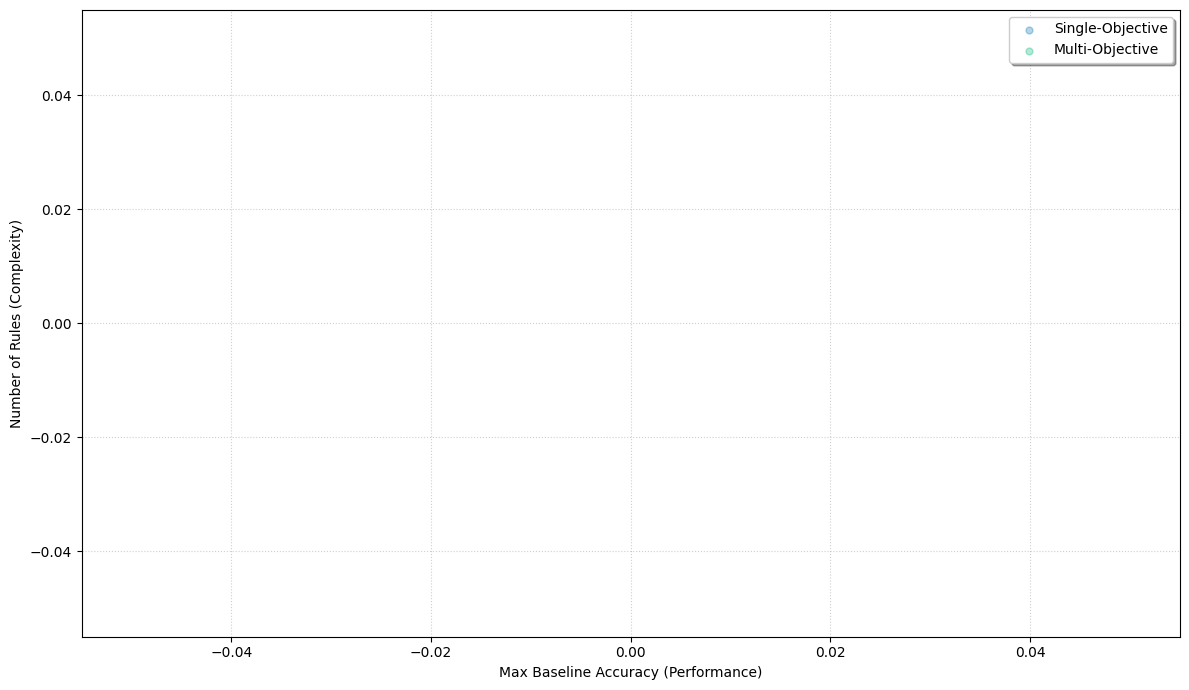

In [3]:
def get_conditions_vs_performance_df(directory, performance_metric="max_in_distribution_accuracy"):
    all_conditions = []
    all_performance = []

    file_pattern = os.path.join(directory, "**/experiment_stats.csv")

    for file_path in glob.glob(file_pattern, recursive=True):
        print(f"Found stats file: {file_path}")
        parent_dir = os.path.dirname(file_path)

        # stats_file = os.path.join(file_path, "experiment_stats.csv")
        df = pd.read_csv(file_path)

        top_rule_sets = df["cid_" + performance_metric]
        top_num_rules = []

        missing_count = 0
        for rule_name in top_rule_sets:
            iteration, num = rule_name.split("_")
            rule_set_dir = parent_dir + "/" + iteration
            rule_file_path = rule_set_dir + "/" + rule_name + ".rules"

            try:
                # Open and parse the JSON file
                with open(rule_file_path, 'r') as f:
                    rule_data = json.load(f)
                    # Count the number of rule objects in the 'rules' list
                    num_rules = len(rule_data.get("rules", []))
                    top_num_rules.append(num_rules)
                
            except FileNotFoundError:
                print(f"File not found: {rule_file_path}")
                top_num_rules.append(None)
                missing_count += 1
        print("Files missing:", missing_count)

        performance = df[performance_metric]

        all_conditions.extend(top_num_rules)
        all_performance.extend(performance)
    

    plot_df = pd.DataFrame({
        'num_rules': all_conditions,
        'performance': all_performance
    }).dropna()

    return plot_df


def plot_pareto_front(plot_df):
    plot_df = plot_df[5:]

    # 2. Calculate Pareto Front (Minimizing Complexity for a given Performance)
    # Sort by performance (x-axis) ascending
    df_sorted = plot_df.sort_values(by=['performance', 'num_rules'], ascending=[True, True])

    pareto_front = []
    current_min_rules = float('inf')

    # To find the front where we minimize rules for a target performance, 
    # we iterate backwards from highest performance
    df_sorted_desc = plot_df.sort_values(by=['performance', 'num_rules'], ascending=[False, True])
    current_min_rules = float('inf')

    for _, row in df_sorted_desc.iterrows():
        if row['num_rules'] < current_min_rules:
            pareto_front.append((row['performance'], row['num_rules']))
            current_min_rules = row['num_rules']

    # Sort back for plotting the line
    pareto_front.sort()
    pareto_x, pareto_y = zip(*pareto_front)

    # 3. Create Visualization
    plt.figure(figsize=(10, 6))

    jitter = np.random.uniform(-0.2, 0.2, size=len(plot_df))
    # Plot all data points (Performance on X, Num Rules on Y)
    plt.scatter(plot_df['performance'], plot_df['num_rules'] + jitter, 
                color='royalblue', alpha=0.5, label='All Rule Sets', s=30)

    # Plot the Pareto Front line
    # 'where=pre' or 'post' depends on how you want the staircase to look
    plt.step(pareto_x, pareto_y, where='post', color='crimson', 
            linewidth=2, label='Pareto Front', zorder=10)

    # Highlight the points on the Pareto Front
    plt.scatter(pareto_x, pareto_y, color='crimson', s=60, edgecolors='black', zorder=11)

    # Swapped Labels
    plt.xlabel('Max Baseline Accuracy (Performance)')
    plt.ylabel('Number of Rules (Complexity)')
    plt.title('Performance vs. Rule Set Complexity')

    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    # plt.savefig('pareto_analysis_swapped.png')
    plt.show()

def plot_dual_pareto(df_blue, df_green, label1="Set A", label2="Set B"):
    def get_pareto_points(df):
        """Helper to calculate the Pareto front (min complexity for max performance)."""
        # Sort by performance descending, then num_rules ascending
        df_sorted = df.sort_values(by=['performance', 'num_rules'], ascending=[False, True])
        
        pareto_front = []
        current_min_rules = float('inf')

        for _, row in df_sorted.iterrows():
            if row['num_rules'] < current_min_rules:
                pareto_front.append((row['performance'], row['num_rules']))
                current_min_rules = row['num_rules']

        pareto_front.sort()
        return zip(*pareto_front) if pareto_front else ([], [])


    plt.figure(figsize=(12, 7))

    datasets = [
        {'df': df_blue, 'color': '#0077b6', 'label': label1},
        {'df': df_green, 'color': "#00b679", 'label': label2}
    ]

    for data in datasets:
        df = data['df'].copy()
        color = data['color']
        label = data['label']

        # 1. Calculate Pareto Front
        px, py = get_pareto_points(df)

        # 2. Plot All Points (with jitter)
        jitter = np.random.uniform(-0.15, 0.15, size=len(df))
        plt.scatter(df['performance'], df['num_rules'] + jitter, 
                    color=color, alpha=0.3, s=25, label=f'{label}')

        # 3. Plot Pareto Line (Staircase)
        # plt.step(px, py, where='post', color=color, 
        #         linewidth=2.5, label=f'{label} Pareto', zorder=10)

        # 4. Highlight Pareto Points
        # plt.scatter(px, py, color=color, s=70, edgecolors='black', zorder=11)

    # Formatting

    # plt.figure(figsize=(10, 6), dpi=120)
    # sns.set_context("notebook", font_scale=1.1)
    # sns.set_style("white")
    # plt.grid(axis='y', linestyle=':', alpha=0.5) # Subtle horizontal guides


    plt.xlabel('Max Baseline Accuracy (Performance)')
    plt.ylabel('Number of Rules (Complexity)')
    # plt.title('Performance vs. Rule Set Complexity: Comparison')
    
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# experiment_dir = "../../../neurorule-data/single-objective/bc/ID/0.95/"
# plot_df = get_conditions_vs_performance_df(experiment_dir)
# plot_pareto_front(plot_df)


dataset = "heart/ID/0.90"

dir1 = "../../../neurorule-data/single-objective/" + dataset + "/"
dir2 = "../../../neurorule-data/multi-objective/" + dataset + "/"
df1 = get_conditions_vs_performance_df(dir1)
df2 = get_conditions_vs_performance_df(dir2)
plot_dual_pareto(df1, df2, label1="Single-Objective", label2="Multi-Objective")


